In [4]:
import sys
!{sys.executable} -m pip install lightgbm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 18.9 MB/s eta 0:00:0031m18.7 MB/s eta 0:00:01


Training shape: (12931, 127)
Evaluation shape: (380, 120)

=== Evaluating HomeWin ===

=== Algorithm Comparison ===
Random Forest: Accuracy=0.6458, F1=0.6023
GradientBoosting: Accuracy=0.6528, F1=0.6025
Logistic Regression: Accuracy=0.6534, F1=0.5988
MLP Neural Net: Accuracy=0.5958, F1=0.5484
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best RF parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1-score: 0.5981732031938495
Classification report (best RF grid search):
              precision    recall  f1-score   support

           0       0.66      0.76      0.71       846
           1       0.67      0.56      0.61       735

    accuracy                           0.67      1581
   macro avg       0.67      0.66      0.66      1581
weighted avg       0.67      0.67      0.66      1581


Best accuracy: 0.6660 at threshold: 0.50


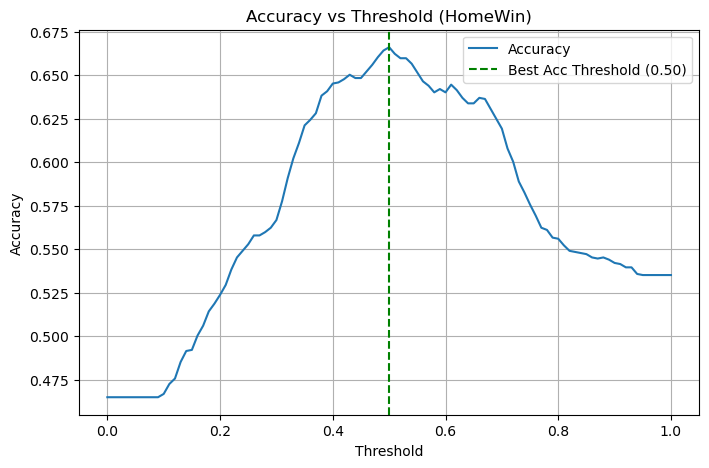


Best threshold for F1: 0.347
F1-score at best threshold: 0.678
Precision at best threshold: 0.560
Recall at best threshold: 0.857

Classification report (best F1 threshold):
              precision    recall  f1-score   support

           0       0.77      0.42      0.54       846
           1       0.56      0.86      0.68       735

    accuracy                           0.62      1581
   macro avg       0.67      0.64      0.61      1581
weighted avg       0.67      0.62      0.60      1581



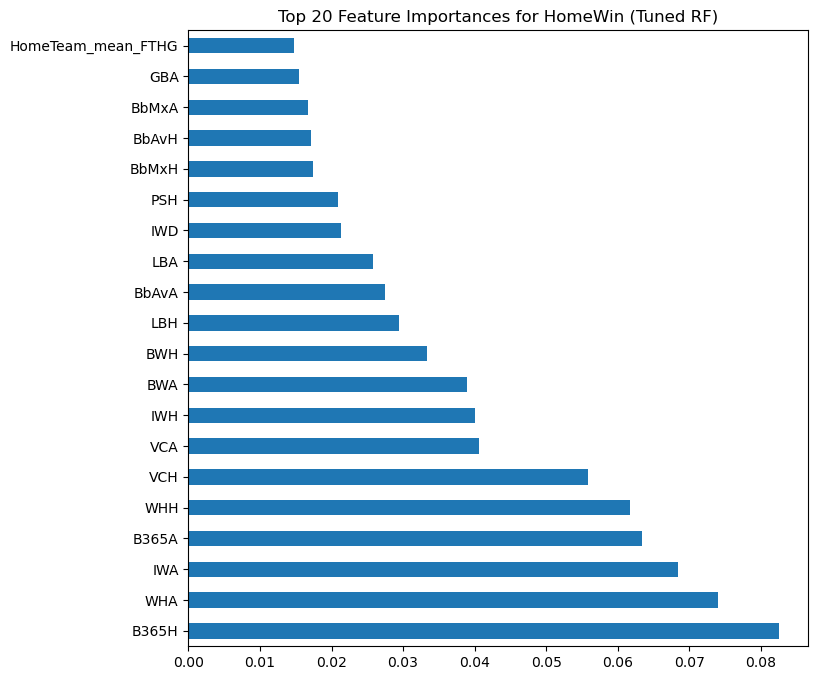


Top Feature Importances:
B365H                 0.082487
WHA                   0.074060
IWA                   0.068454
B365A                 0.063390
WHH                   0.061684
VCH                   0.055858
VCA                   0.040612
IWH                   0.040017
BWA                   0.038935
BWH                   0.033376
LBH                   0.029413
BbAvA                 0.027480
LBA                   0.025854
IWD                   0.021300
PSH                   0.020868
BbMxH                 0.017418
BbAvH                 0.017116
BbMxA                 0.016731
GBA                   0.015422
HomeTeam_mean_FTHG    0.014814


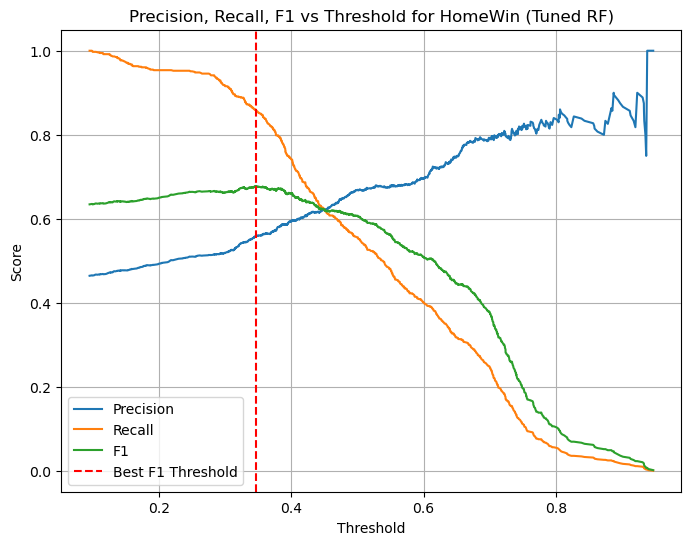

Saved best RF model for HomeWin to ../../models/thirdIterration/rf_HomeWin_best.pkl
Saved feature list for HomeWin to ../../models/thirdIterration/rf_HomeWin_feature_list.pkl

=== Misclassified Matches (False Positives & False Negatives) ===
 HFKC  AFKC  B365H  B365D  B365A  B365>2.5  B365<2.5  B365AHH  B365AHA    B365AH  BFDH  BFDD  BFDA  BMGMH  BMGMD  BMGMA  BVH  BVD  BVA   VCH  VCD   VCA      BSH      BSD      BSA   BWH  BWD   BWA  CLH  CLD  CLA      GBH      GBD      GBA   GB>2.5   GB<2.5   GBAHH    GBAHA      GBAH   IWH  IWD   IWA      LBH      LBD       LBA    LBAHH    LBAHA      LBAH       PSH  PH      PSD  PD       PSA  PA    P>2.5    P<2.5     PAHH     PAHA     SOH      SOD      SOA      SBH      SBD      SBA      SJH      SJD      SJA   WHH  WHD   WHA  Bb1X2    BbMxH    BbAvH    BbMxD    BbAvD    BbMxA     BbAvA    BbOU  BbMx>2.5  BbAv>2.5  BbMx<2.5  BbAv<2.5     BbAH     BbAHh  BbMxAHH  BbAvAHH  BbMxAHA  BbAvAHA    MaxH     MaxD    MaxA      AvgH     AvgD     AvgA  Max>2.5  

In [3]:
import pandas as pd
import numpy as np
import os
import re
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, precision_recall_curve, accuracy_score, f1_score
import matplotlib.pyplot as plt
import joblib
pd.set_option('display.max_columns', None)

train_df = pd.read_csv("../../data/processed/combinedWithOdds.csv")
eval_df = pd.read_csv("../../data/evaluation/secondIterration/202425.csv")

print("Training shape:", train_df.shape)
print("Evaluation shape:", eval_df.shape)

columns_to_keep = [
    'Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR',
    'HTHG', 'HTAG', 'HTR', 'Attendance', 'Referee', 'HS', 'AS', 'HST', 'AST',
    'HHW', 'AHW', 'HC', 'AC', 'HF', 'AF', 'HFKC', 'AFKC', 'HO', 'AO', 'HY', 'AY',
    'HR', 'AR', '1XBH', '1XBD', '1XBA', 'B365H', 'B365D', 'B365A', 'B365>2.5', 'B365<2.5', 'B365AHH', 'B365AHA', 'B365AH',
    'BFH', 'BFD', 'BFA', 'BFEH', 'BFED', 'BFEA', 'BFDH', 'BFDD', 'BFDA',
    'BMGMH', 'BMGMD', 'BMGMA', 'BVH', 'BVD', 'BVA', 'VCH', 'VCD', 'VCA',
    'BSH', 'BSD', 'BSA', 'BWH', 'BWD', 'BWA', 'CLH', 'CLD', 'CLA',
    'GBH', 'GBD', 'GBA', 'GB>2.5', 'GB<2.5', 'GBAHH', 'GBAHA', 'GBAH',
    'IWH', 'IWD', 'IWA', 'LBH', 'LBD', 'LBA', 'LBAHH', 'LBAHA', 'LBAH',
    'PSH', 'PH', 'PSD', 'PD', 'PSA', 'PA', 'P>2.5', 'P<2.5', 'PAHH', 'PAHA',
    'SOH', 'SOD', 'SOA', 'SBH', 'SBD', 'SBA', 'SJH', 'SJD', 'SJA',
    'SYH', 'SYD', 'SYA', 'WHH', 'WHD', 'WHA',
    'Bb1X2', 'BbMxH', 'BbAvH', 'BbMxD', 'BbAvD', 'BbMxA', 'BbAvA',
    'BbOU', 'BbMx>2.5', 'BbAv>2.5', 'BbMx<2.5', 'BbAv<2.5',
    'BbAH', 'BbAHh', 'BbMxAHH', 'BbAvAHH', 'BbMxAHA', 'BbAvAHA',
    'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA',
    'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5',
    'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'AHh'
]

for df_ in [train_df, eval_df]:
    for col in columns_to_keep:
        if col not in df_.columns:
            df_[col] = 0
    df_ = df_[columns_to_keep]

train_df = train_df[columns_to_keep]
eval_df = eval_df[columns_to_keep]

def clean_and_engineer_features(
    df,
    columns_to_keep,
    all_teams=None, 
    fit_teams=False,
    n_matches=5,
    drop_cols=['Time', 'Attendance', 'HHW', 'AHW', 'HO', 'AO', 'Div'],
):
    for col in columns_to_keep:
        if col not in df.columns:
            df[col] = np.nan
    df = df[columns_to_keep].copy()
    df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')

    # Date parsing
    def date_format_type(date_str):
        if not isinstance(date_str, str):
            return "not_a_string"
        patterns = {
            "%d/%m/%y": r"^\d{2}/\d{2}/\d{2}$",
            "%d/%m/%Y": r"^\d{2}/\d{2}/\d{4}$",
            "%Y-%m-%d": r"^\d{4}-\d{2}-\d{2}$",
            "%m-%d-%Y": r"^\d{2}-\d{2}-\d{4}$",
            "%Y/%m/%d": r"^\d{4}/\d{2}/\d{2}$",
        }
        for fmt, pat in patterns.items():
            if re.match(pat, date_str):
                return fmt
        return "unknown"
    df['DateFormat'] = df['Date'].apply(date_format_type)
    def parse_dates(row):
        date_str = row['Date']
        if isinstance(date_str, str):
            try:
                return pd.to_datetime(date_str, format='%d/%m/%y')
            except ValueError:
                try:
                    return pd.to_datetime(date_str, format='%d/%m/%Y')
                except ValueError:
                    return pd.NaT
        else:
            return pd.NaT
    df['Date'] = df.apply(parse_dates, axis=1)
    df = df.drop(columns=['DateFormat'], errors='ignore')
    df = df[df['Date'] >= pd.Timestamp('2000-08-18')]
    df = df.reset_index(drop=True)

    def get_season(date):
        if pd.isnull(date):
            return np.nan
        year = date.year
        month = date.month
        if month >= 8:
            return f"{year}-{str(year+1)[-2:]}"
        else:
            return f"{year-1}-{str(year)[-2:]}"
    newcols = {
        'Season': df['Date'].apply(get_season),
        'Year': df['Date'].dt.year,
        'Month': df['Date'].dt.month,
        'DayOfWeek': df['Date'].dt.dayofweek,
        'HomeWin': (df['FTR'] == 'H').astype(int),
    }
    df = pd.concat([df, pd.DataFrame(newcols, index=df.index)], axis=1)

    odds_cols = [
        'B365H', 'B365D', 'B365A', 'B365>2.5', 'B365<2.5', 'B365AHH', 'B365AHA', 'B365AH',
        'IWH', 'IWD', 'IWA', 'WHH', 'WHD', 'WHA', 'PSH', 'PSD', 'PSA', 'PH', 'PD', 'PA',
        'P>2.5', 'P<2.5', 'PAHH', 'PAHA', 'LBH', 'LBD', 'LBA', 'LBAHH', 'LBAHA', 'LBAH',
        'GBH', 'GBD', 'GBA', 'GB>2.5', 'GB<2.5', 'GBAHH', 'GBAHA', 'GBAH', 'BVH', 'BVD', 'BVA',
        'VCH', 'VCD', 'VCA', '1XBH', '1XBD', '1XBA', 'BWH', 'BWD', 'BWA', 'SOH', 'SOD', 'SOA',
        'SBH', 'SBD', 'SBA', 'CLH', 'CLD', 'CLA', 'BMGMH', 'BMGMD', 'BMGMA', 'BFDH', 'BFDD', 'BFDA',
        'BFH', 'BFD', 'BFA', 'BFEH', 'BFED', 'BFEA', 'SYH', 'SYD', 'SYA', 'SJH', 'SJD', 'SJA',
        'BSH', 'BSD', 'BSA', 'BbMxH', 'BbAvH', 'BbMxD', 'BbAvD', 'BbMxA', 'BbAvA', 'BbOU',
        'BbMx>2.5', 'BbAv>2.5', 'BbMx<2.5', 'BbAv<2.5', 'BbAH', 'BbAHh', 'BbMxAHH', 'BbAvAHH',
        'BbMxAHA', 'BbAvAHA', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'Max>2.5', 'Max<2.5',
        'Avg>2.5', 'Avg<2.5', 'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'AHh'
    ]
    score_cols = [
        'FTHG', 'FTAG', 'HTHG', 'HTAG', 'HS', 'AS', 'HST', 'AST',
        'HC', 'AC', 'HF', 'AF', 'HY', 'AY', 'HR', 'AR'
    ]
    for col in odds_cols + score_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.drop_duplicates()

    essential_odds = ['B365H', 'B365D', 'B365A', 'WHH', 'WHD', 'WHA', 'IWH', 'IWD', 'IWA']
    core_odds = odds_cols
    essentials = [col for col in essential_odds if col in df.columns]
    df = df.dropna(subset=essentials).reset_index(drop=True)
    for col in core_odds:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].mean())

    df = df.sort_values('Date')
    roll_features = {
        'HomeTeam_mean_FTHG': df.groupby('HomeTeam')['FTHG'].transform(lambda x: x.shift(1).expanding().mean()),
        'AwayTeam_mean_FTAG': df.groupby('AwayTeam')['FTAG'].transform(lambda x: x.shift(1).expanding().mean()),
        'HomeTeam_str': df['HomeTeam'],
        'AwayTeam_str': df['AwayTeam'],
    }
    df = pd.concat([df, pd.DataFrame(roll_features, index=df.index)], axis=1)

    if fit_teams:
        unique_teams = sorted(set(df['HomeTeam_str']).union(set(df['AwayTeam_str'])))
    else:
        unique_teams = all_teams

    team_onehot = {}
    for team in unique_teams:
        team_onehot[f"HomeTeam_{team}"] = (df['HomeTeam_str'] == team).astype(int)
        team_onehot[f"AwayTeam_{team}"] = (df['AwayTeam_str'] == team).astype(int)
    df = pd.concat([df, pd.DataFrame(team_onehot, index=df.index)], axis=1)
    df = df.drop(columns=['HomeTeam', 'AwayTeam'], errors='ignore')
    df = df.rename(columns={'HomeTeam_str': 'HomeTeam', 'AwayTeam_str': 'AwayTeam'})

    def add_recent_form_features(df, n_matches=5):
        base = df.copy()
        base = base.sort_values('Date')
        home_df = base[['Date', 'HomeTeam', 'FTHG', 'FTAG']].rename(
            columns={'HomeTeam': 'Team', 'FTHG': 'GoalsFor', 'FTAG': 'GoalsAgainst'})
        away_df = base[['Date', 'AwayTeam', 'FTAG', 'FTHG']].rename(
            columns={'AwayTeam': 'Team', 'FTAG': 'GoalsFor', 'FTHG': 'GoalsAgainst'})
        results = pd.concat([home_df, away_df], ignore_index=True)
        results = results.sort_values(['Team', 'Date'])
        def get_points(row):
            return 3 if row['GoalsFor'] > row['GoalsAgainst'] else (1 if row['GoalsFor'] == row['GoalsAgainst'] else 0)
        results['Points'] = results.apply(get_points, axis=1)
        results['RollingGF'] = results.groupby('Team')['GoalsFor'].transform(lambda x: x.shift(1).rolling(n_matches, min_periods=1).mean())
        results['RollingGA'] = results.groupby('Team')['GoalsAgainst'].transform(lambda x: x.shift(1).rolling(n_matches, min_periods=1).mean())
        results['RollingPoints'] = results.groupby('Team')['Points'].transform(lambda x: x.shift(1).rolling(n_matches, min_periods=1).sum())
        def get_form(row, team_col):
            team = row[team_col]
            date = row['Date']
            row_form = results[(results['Team'] == team) & (results['Date'] < date)].sort_values('Date').tail(1)
            if row_form.empty:
                return pd.Series([np.nan, np.nan, np.nan])
            return row_form[['RollingGF', 'RollingGA', 'RollingPoints']].values[0]
        base[['HomeRecentGF', 'HomeRecentGA', 'HomeRecentPts']] = base.apply(
            lambda row: get_form(row, 'HomeTeam'), axis=1, result_type='expand')
        base[['AwayRecentGF', 'AwayRecentGA', 'AwayRecentPts']] = base.apply(
            lambda row: get_form(row, 'AwayTeam'), axis=1, result_type='expand')
        return base
    df = add_recent_form_features(df, n_matches=n_matches)
    df = df.dropna(subset=['HomeRecentGF', 'AwayRecentGF'])

    df = df.replace([np.inf, -np.inf], np.nan)
    for col in df.select_dtypes(include=['number']):
        df[col] = df[col].fillna(df[col].median())
    for col in df.select_dtypes(include=['object', 'category']):
        df[col] = df[col].fillna(df[col].mode()[0])
    df = df.drop_duplicates().reset_index(drop=True)

    threshold = 0.95
    df = df.loc[:, df.isnull().mean() < threshold]
    df = df.copy()
    return df, unique_teams if fit_teams else all_teams

train_df_clean, all_teams = clean_and_engineer_features(train_df, columns_to_keep, fit_teams=True)
eval_df_clean, _ = clean_and_engineer_features(eval_df, columns_to_keep, all_teams=all_teams)

cols_to_drop = [
    'GoalsOver2_5', 'TotalGoals', 'FTHG', 'FTAG',
    'HTHG', 'HTAG',
    'HS', 'AS', 'HST', 'AST',
    'HC', 'AC',
    'HF', 'AF',
    'HY', 'AY',
    'HR', 'AR',
    'FTR_H', 'FTR_A', 'FTR_D',
    'HTR_H', 'HTR_A', 'HTR_D',
    'FTR', 'HTR',
    'HomeTeam', 'AwayTeam',
    'Date', 'Referee',
    'Season',
    'HomeGoalDiff', 'AwayGoalDiff',
    'HomePts', 'AwayPts',
    'BTTS', 'Away_2plus', 'Home_2plus',
    'target_home_plus_two', 'target_away_plus_two',
    'HomeWin' 
]

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

def train_homewin_rf(df, cols_to_drop, param_grid):
    target_col = 'HomeWin'
    print(f"\n=== Evaluating {target_col} ===")
    X = df.drop(columns=cols_to_drop, errors='ignore')
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    algorithms = {
        "Random Forest": RandomForestClassifier(random_state=42),
        "GradientBoosting": GradientBoostingClassifier(random_state=42),
        "Logistic Regression": make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=2000, random_state=42)
        ),
        "MLP Neural Net": make_pipeline(
            StandardScaler(),
            MLPClassifier(random_state=42, max_iter=1000)
        ),
    }
    
    print("\n=== Algorithm Comparison ===")
    for name, clf in algorithms.items():
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        print(f"{name}: Accuracy={acc:.4f}, F1={f1:.4f}")

    grid_search = GridSearchCV(
        RandomForestClassifier(random_state=42),
        param_grid,
        cv=3,
        scoring='f1',
        n_jobs=-1,
        verbose=2
    )
    grid_search.fit(X_train, y_train)

    print("Best RF parameters:", grid_search.best_params_)
    print("Best CV F1-score:", grid_search.best_score_)

    best_rf = grid_search.best_estimator_
    y_pred_grid = best_rf.predict(X_test)
    print("Classification report (best RF grid search):")
    print(classification_report(y_test, y_pred_grid))

    y_probs_grid = best_rf.predict_proba(X_test)[:, 1]

    thresholds = np.linspace(0, 1, 101)
    accuracies = []
    best_acc = 0
    best_acc_thresh = 0.5

    for t in thresholds:
        y_pred_acc = (y_probs_grid >= t).astype(int)
        acc = accuracy_score(y_test, y_pred_acc)
        accuracies.append(acc)
        if acc > best_acc:
            best_acc = acc
            best_acc_thresh = t

    print(f"\nBest accuracy: {best_acc:.4f} at threshold: {best_acc_thresh:.2f}")

    plt.figure(figsize=(8,5))
    plt.plot(thresholds, accuracies, label='Accuracy')
    plt.axvline(best_acc_thresh, color='g', linestyle='--', label=f'Best Acc Threshold ({best_acc_thresh:.2f})')
    plt.xlabel('Threshold')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs Threshold (HomeWin)')
    plt.legend()
    plt.grid()
    plt.show()
    
    precision, recall, thresholds = precision_recall_curve(y_test, y_probs_grid)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_idx = np.argmax(f1[:-1])
    best_threshold = thresholds[best_idx]
    print(f"\nBest threshold for F1: {best_threshold:.3f}")
    print(f"F1-score at best threshold: {f1[best_idx]:.3f}")
    print(f"Precision at best threshold: {precision[best_idx]:.3f}")
    print(f"Recall at best threshold: {recall[best_idx]:.3f}")

    y_pred_best = (y_probs_grid >= best_threshold).astype(int)
    print("\nClassification report (best F1 threshold):")
    print(classification_report(y_test, y_pred_best))

    feat_importances = pd.Series(best_rf.feature_importances_, index=X.columns)
    feat_importances.nlargest(20).plot(kind='barh', figsize=(8, 8))
    plt.title(f'Top 20 Feature Importances for {target_col} (Tuned RF)')
    plt.show()

    top_n = 20 
    top_feats = feat_importances.sort_values(ascending=False).head(top_n)
    print("\nTop Feature Importances:")
    print(top_feats.to_string())

    plt.figure(figsize=(8,6))
    plt.plot(thresholds, precision[:-1], label='Precision')
    plt.plot(thresholds, recall[:-1], label='Recall')
    plt.plot(thresholds, f1[:-1], label='F1')
    plt.axvline(best_threshold, color='r', linestyle='--', label='Best F1 Threshold')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title(f'Precision, Recall, F1 vs Threshold for {target_col} (Tuned RF)')
    plt.legend()
    plt.grid()
    plt.show()

    return best_rf, best_threshold, X_test, y_test, y_pred_best

best_rf, best_threshold, X_test, y_test, y_pred_best = train_homewin_rf(train_df_clean, cols_to_drop, param_grid)

target_col = "HomeWin"
X_train = train_df_clean.drop(columns=[target_col])
feature_list = X_train.columns.tolist()

output_dir = "../../models/thirdIterration/"
os.makedirs(output_dir, exist_ok=True)
model_filename = os.path.join(output_dir, f"rf_{target_col}_best.pkl")
feature_list_filename = os.path.join(output_dir, f"rf_{target_col}_feature_list.pkl")
joblib.dump(best_rf, model_filename)
joblib.dump(feature_list, feature_list_filename)

print(f"Saved best RF model for {target_col} to {model_filename}")
print(f"Saved feature list for {target_col} to {feature_list_filename}")

eval_df_clean.to_csv("../../data/evaluation/secondIterration/eval_df_clean.csv", index=False)

misclassified = X_test.copy()
misclassified['Actual'] = y_test.values
misclassified['Predicted'] = y_pred_best

false_positives = misclassified[(misclassified['Predicted'] == 1) & (misclassified['Actual'] == 0)]
false_negatives = misclassified[(misclassified['Predicted'] == 0) & (misclassified['Actual'] == 1)]

fp_sample = false_positives.sample(n=min(5, len(false_positives)), random_state=42)
fn_sample = false_negatives.sample(n=min(5, len(false_negatives)), random_state=42) 
samples = pd.concat([fp_sample, fn_sample])

valid_columns = [c for c in columns_to_keep if c in samples.columns]
print("\n=== Misclassified Matches (False Positives & False Negatives) ===")
print(samples[valid_columns + ['Actual', 'Predicted']].to_string(index=False))